<a href="https://colab.research.google.com/github/udekontee/Cyclistic-Bike-Share-Analysis/blob/main/Cyclistic_Bike_Share_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cyclistic Bike-Share Analysis

## Google Data Analytics Capstone Case Study

### Project Overview

This case study analyzes Cyclistic bike-share trip data to understand how casual riders and annual members use the service differently. The goal is to identify behavioral patterns that can support marketing strategies aimed at converting casual riders into annual members.

The analysis uses the most recent 12 complete months of publicly available Divvy trip data, covering September 2025 through August 2026.

---

## 1. Ask

### Business Task

Cyclistic wants to increase the number of annual memberships. The purpose of this analysis is to determine how casual riders and annual members use Cyclistic bikes differently and identify behavioral trends that can support strategies for converting casual riders into annual members.

### Primary Business Question

**How do annual members and casual riders use Cyclistic bikes differently?**

### Key Stakeholders

- Lily Moreno — Director of Marketing
- Cyclistic Marketing Analytics Team
- Cyclistic Executive Team

## 2. Prepare

### Data Source

This analysis uses publicly available Divvy trip data provided for the Cyclistic case study. Divvy is a bike-share system in Chicago, and the dataset contains individual bike trips made by casual riders and annual members.

For this updated analysis, the most recent 12 complete months of trip data were selected, covering **September 2025 through August 2026**.

### Files Used

The analysis includes 12 monthly CSV files:

- 202509-divvy-tripdata.csv
- 202510-divvy-tripdata.csv
- 202511-divvy-tripdata.csv
- 202512-divvy-tripdata.csv
- 202601-divvy-tripdata.csv
- 202602-divvy-tripdata.csv
- 202603-divvy-tripdata.csv
- 202604-divvy-tripdata.csv
- 202605-divvy-tripdata.csv
- 202606-divvy-tripdata.csv
- 202607-divvy-tripdata.csv
- 202608-divvy-tripdata.csv

### Data Preparation Approach

Before analysis, the monthly datasets will be inspected to verify their structure, column names, data types, missing values, and consistency across files. The 12 monthly datasets will then be combined into a single dataset for cleaning and analysis.

The data will be evaluated for duplicate records, missing values, invalid trip durations, and other quality issues before answering the business question.

## 3. Process

### Combining and Cleaning the Data

The 12 monthly CSV files were combined into a single DataFrame to create one complete dataset covering September 2025 through August 2026.

Before analysis, the combined dataset was evaluated for data-quality issues including duplicate ride IDs, missing values, incorrect data types, and invalid trip durations.

Additional variables will be created from the trip timestamps to support analysis of rider behavior by ride duration, day of the week, month, and other time-based patterns.

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import glob
import os

folder_path = "/content/drive/MyDrive/Cyclistic_2025_2026"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

print("Number of CSV files found:", len(csv_files))

for file in sorted(csv_files):
    print(os.path.basename(file))

Number of CSV files found: 12
202509-divvy-tripdata.csv
202510-divvy-tripdata.csv
202511-divvy-tripdata.csv
202512-divvy-tripdata.csv
202601-divvy-tripdata.csv
202602-divvy-tripdata.csv
202603-divvy-tripdata.csv
202604-divvy-tripdata.csv
202605-divvy-tripdata.csv
202606-divvy-tripdata.csv
202607-divvy-tripdata.csv
202608-divvy-tripdata.csv


In [5]:
for file in sorted(csv_files):
    sample = pd.read_csv(file, nrows=5)

    print(os.path.basename(file))
    print(sample.columns.tolist())
    print()

202509-divvy-tripdata.csv
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']

202510-divvy-tripdata.csv
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']

202511-divvy-tripdata.csv
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']

202512-divvy-tripdata.csv
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']

202601-divvy-tripdata.csv
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_stat

In [8]:
jan_file = "/content/drive/MyDrive/Cyclistic_2025_2026/202601-divvy-tripdata.csv"

jan_check = pd.read_csv(
    jan_file,
    usecols=["started_at", "ended_at"],
    nrows=10
)

jan_check

,started_at,ended_at
0,2026-01-31 09:13:09.018,2026-01-31 09:28:10.302
1,2026-01-15 14:25:42.526,2026-01-15 14:33:18.854
2,2026-01-06 12:55:33.572,2026-01-06 13:02:17.922
3,2026-01-26 16:22:25.011,2026-01-26 16:53:15.197
4,2026-01-10 18:13:30.139,2026-01-10 19:31:56.971
5,2026-01-06 18:15:56.869,2026-01-06 19:50:49.713
6,2026-01-28 15:25:12.620,2026-01-28 15:27:03.818
7,2026-01-09 17:30:33.273,2026-01-09 17:33:28.779
8,2026-01-09 13:18:30.185,2026-01-09 13:21:20.190
9,2026-01-08 14:19:30.047,2026-01-08 14:25:54.180


In [9]:
dataframes = []

for file in sorted(csv_files):
    monthly_data = pd.read_csv(file)
    dataframes.append(monthly_data)

cyclistic = pd.concat(dataframes, ignore_index=True)

print("Combined dataset shape:", cyclistic.shape)

cyclistic.head()

Combined dataset shape: (6115982, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,B0AD82B8A2556E7C,electric_bike,2025-09-01 12:05:13.323,2025-09-01 12:25:19.273,NaN,NaN,NaN,NaN,41.91,-87.63,41.96,-87.64,member
1,DCC4ABF0F7DCCE6A,electric_bike,2025-09-01 01:41:00.775,2025-09-01 01:48:59.228,NaN,NaN,NaN,NaN,41.95,-87.67,41.95,-87.65,member
2,C27785FFE7568433,electric_bike,2025-09-01 07:16:13.921,2025-09-01 07:39:51.831,NaN,NaN,NaN,NaN,41.94,-87.65,41.98,-87.65,member
3,812DB2D3AD2F18EB,electric_bike,2025-09-01 09:31:36.294,2025-09-01 09:49:08.022,NaN,NaN,NaN,NaN,41.98,-87.65,41.94,-87.65,member
4,61F6BD3174DC4E84,electric_bike,2025-09-26 08:51:58.069,2025-09-26 09:07:29.290,NaN,NaN,NaN,NaN,41.90,-87.69,41.87,-87.65,member


In [10]:
print("Dataset shape:", cyclistic.shape)

print("\nData types:")
print(cyclistic.dtypes)

print("\nMissing values:")
print(cyclistic.isna().sum())

print("\nDuplicate ride IDs:")
print(cyclistic["ride_id"].duplicated().sum())

print("\nRider categories:")
print(cyclistic["member_casual"].value_counts())

Dataset shape: (6115982, 13)

Data types:
ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object

Missing values:
ride_id                     0
rideable_type               0
started_at                  0
ended_at                    0
start_station_name    1285406
start_station_id      1285406
end_station_name      1349937
end_station_id        1349937
start_lat                   0
start_lng                   0
end_lat                  5426
end_lng                  5426
member_casual               0
dtype: int64

Duplicate ride IDs:
35

Rider categories:
member_casual
member    3955617
casual    2160365
Name: count, dtype: int64


### 3.3 Data Cleaning

The initial inspection identified several data-quality issues. The combined dataset contained 35 duplicate ride IDs, and the trip start and end timestamps were stored as text rather than datetime values.

A substantial number of records also contained missing station names and station IDs. These records were not automatically removed because they may still contain valid trip timestamps, rider type, and location information that can be used for behavioral analysis.

The cleaning process therefore focuses on removing duplicate rides, converting timestamps to datetime format, calculating ride duration, and removing records with invalid trip durations.

In [11]:
# Create a working copy
cyclistic_clean = cyclistic.copy()

# Remove duplicate ride IDs
cyclistic_clean = cyclistic_clean.drop_duplicates(
    subset="ride_id"
).copy()

# Convert timestamps to datetime
cyclistic_clean["started_at"] = pd.to_datetime(
    cyclistic_clean["started_at"]
)

cyclistic_clean["ended_at"] = pd.to_datetime(
    cyclistic_clean["ended_at"]
)

# Calculate ride duration in minutes
cyclistic_clean["ride_length_min"] = (
    cyclistic_clean["ended_at"] -
    cyclistic_clean["started_at"]
).dt.total_seconds() / 60

# Check ride-duration distribution
cyclistic_clean["ride_length_min"].describe()

,ride_length_min
count,6.115947e+06
mean,1.530917e+01
std,5.147282e+01
min,-5.479480e+01
25%,5.330058e+00
50%,9.263283e+00
75%,1.615772e+01
max,1.559950e+03


### 3.4 Validating Ride Duration

Ride duration was calculated as the difference between the trip end and start timestamps. The initial distribution revealed negative ride durations and unusually long trips.

Before removing records, these observations were examined to determine appropriate cleaning rules and document how many records would be affected.

In [13]:
# Count zero or negative ride durations
invalid_duration = (
    cyclistic_clean["ride_length_min"] <= 0
).sum()

# Count rides longer than 24 hours
over_24_hours = (
    cyclistic_clean["ride_length_min"] > 1440
).sum()

print("Zero or negative duration rides:", invalid_duration)
print("Rides longer than 24 hours:", over_24_hours)

Zero or negative duration rides: 29
Rides longer than 24 hours: 5302


### 3.5 Removing Invalid Ride Durations

The dataset contained 29 rides with zero or negative ride durations. Because a completed ride cannot have a duration of zero or less, these records were treated as invalid and removed.

Rides longer than 24 hours were not immediately removed. These observations were retained temporarily for further investigation before determining whether they represented legitimate long-duration rentals or data-quality issues.

In [14]:
# Remove rides with zero or negative duration
cyclistic_clean = cyclistic_clean[
    cyclistic_clean["ride_length_min"] > 0
].copy()

print("Dataset shape after removing invalid durations:",
      cyclistic_clean.shape)

print(
    "Remaining zero or negative durations:",
    (cyclistic_clean["ride_length_min"] <= 0).sum()
)

Dataset shape after removing invalid durations: (6115918, 14)
Remaining zero or negative durations: 0


### 3.6 Investigating Extremely Long Rides

A small number of trips lasted longer than 24 hours. Because these records may represent legitimate long-duration rentals or unusual data-quality issues, they were inspected before deciding whether to remove them from the analysis.

In [15]:
long_rides = cyclistic_clean[
    cyclistic_clean["ride_length_min"] > 1440
].copy()

print("Number of rides longer than 24 hours:", len(long_rides))

long_rides[
    [
        "ride_id",
        "rideable_type",
        "started_at",
        "ended_at",
        "ride_length_min",
        "member_casual"
    ]
].sort_values("ride_length_min", ascending=False).head(10)

Number of rides longer than 24 hours: 5302


,ride_id,rideable_type,started_at,ended_at,ride_length_min,member_casual
2264740,C82393BDD3070D5D,classic_bike,2026-03-07 16:07:09.988,2026-03-08 18:07:06.999,1559.950183,casual
2341901,250556580DD308BE,classic_bike,2026-03-07 23:51:38.812,2026-03-09 01:51:33.033,1559.903683,member
2338427,266FF1F3D3203623,classic_bike,2026-03-07 12:29:39.955,2026-03-08 14:29:33.587,1559.893867,casual
2342823,F2DADD2100A676E7,classic_bike,2026-03-07 09:43:11.203,2026-03-08 11:43:04.158,1559.882583,casual
2264872,EB04F9C062AAAF6A,classic_bike,2026-03-07 09:33:18.048,2026-03-08 11:33:09.975,1559.865450,casual
2336652,7CFD1B6B5319BB28,classic_bike,2026-03-07 12:20:32.025,2026-03-08 14:20:23.251,1559.853767,casual
2336655,B35EFB4539BB4B2B,classic_bike,2026-03-07 02:41:16.669,2026-03-08 04:41:03.312,1559.777383,casual
2380917,13769591C639EB0C,classic_bike,2026-03-07 12:45:52.881,2026-03-08 14:45:33.445,1559.676067,member
2220156,A679963188E41606,classic_bike,2026-03-07 14:40:43.466,2026-03-08 16:40:22.698,1559.653867,casual
2341221,FBBF2C15825C4E6F,classic_bike,2026-03-07 12:28:27.947,2026-03-08 14:28:06.578,1559.643850,casual


### 3.7 Investigating the Long-Ride Pattern

The longest rides showed an unusual concentration around 26 hours, with several of the longest observations occurring around the same dates. Rather than automatically treating all rides over 24 hours as invalid, the long-duration records were examined by date, rider type, and duration range to determine whether they represented genuine rider behavior or a systematic data issue.

In [16]:
# Examine long rides by start date
long_rides["start_date"] = long_rides["started_at"].dt.date

print("Top start dates for rides over 24 hours:")
print(long_rides["start_date"].value_counts().head(10))

print("\nLong rides by rider type:")
print(long_rides["member_casual"].value_counts())

print("\nLong ride duration statistics:")
print(long_rides["ride_length_min"].describe())

Top start dates for rides over 24 hours:
start_date
2025-10-12    82
2026-06-13    61
2026-06-06    61
2026-07-19    56
2026-06-07    50
2026-07-25    47
2025-09-28    46
2025-10-18    44
2025-08-31    42
2026-05-16    40
Name: count, dtype: int64

Long rides by rider type:
member_casual
casual    4240
member    1062
Name: count, dtype: int64

Long ride duration statistics:
count    5302.000000
mean     1499.234156
std         5.856700
min      1440.071633
25%      1499.658588
50%      1499.849558
75%      1499.901029
max      1559.950183
Name: ride_length_min, dtype: float64


### 3.8 Removing Extreme Ride Durations

The 5,302 rides lasting longer than 24 hours showed an unusual distribution. Their median duration was approximately 1,500 minutes (25 hours), with very little variation. This concentration suggests that these records may reflect system-related or rental-status anomalies rather than typical rider behavior.

Because these extreme durations could substantially distort comparisons of ride length, particularly because most occurred among casual riders, rides longer than 24 hours were excluded from the behavioral analysis.

In [17]:
# Remove rides longer than 24 hours
cyclistic_clean = cyclistic_clean[
    cyclistic_clean["ride_length_min"] <= 1440
].copy()

print("Dataset shape after duration cleaning:",
      cyclistic_clean.shape)

print("\nRide duration after cleaning:")
print(cyclistic_clean["ride_length_min"].describe())

Dataset shape after duration cleaning: (6110616, 14)

Ride duration after cleaning:
count    6.110616e+06
mean     1.402188e+01
std      2.719229e+01
min      7.666667e-04
25%      5.327033e+00
50%      9.254950e+00
75%      1.613053e+01
max      1.439976e+03
Name: ride_length_min, dtype: float64


### 3.9 Verifying the Analysis Period

The analysis is intended to cover a continuous 12-month period from September 2025 through August 2026. The cleaned timestamps were therefore checked to confirm the earliest and latest trip dates and identify any records falling outside the intended analysis period.

In [18]:
# Check the full date range
print("Earliest start:", cyclistic_clean["started_at"].min())
print("Latest start:", cyclistic_clean["started_at"].max())

# Count rides outside the intended analysis period
period_start = pd.Timestamp("2025-09-01")
period_end = pd.Timestamp("2026-09-01")

outside_period = (
    (cyclistic_clean["started_at"] < period_start) |
    (cyclistic_clean["started_at"] >= period_end)
)

print(
    "Rides outside Sep 2025-Aug 2026:",
    outside_period.sum()
)

Earliest start: 2025-08-31 10:57:37.782000
Latest start: 2026-08-31 23:55:36.979000
Rides outside Sep 2025-Aug 2026: 225


### 3.10 Filtering the Analysis Period

The timestamp validation identified 225 rides that began before September 1, 2025. To maintain a consistent 12-month analysis period, the dataset was restricted to rides beginning between September 1, 2025 and August 31, 2026.

In [19]:
# Keep only rides within the intended 12-month period
cyclistic_clean = cyclistic_clean[
    (cyclistic_clean["started_at"] >= period_start) &
    (cyclistic_clean["started_at"] < period_end)
].copy()

print("Final date range:")
print(cyclistic_clean["started_at"].min())
print(cyclistic_clean["started_at"].max())

print("\nDataset shape:")
print(cyclistic_clean.shape)

Final date range:
2025-09-01 00:00:03.776000
2026-08-31 23:55:36.979000

Dataset shape:
(6110391, 14)


### 3.11 Creating Variables for Analysis

Additional time-based variables were created from the trip start timestamp to support comparisons between casual riders and annual members.

These variables include the trip date, day of the week, month, and hour of the day. Together with ride duration, they will help identify differences in when and how the two rider groups use Cyclistic bikes.

In [20]:
# Create variables for analysis
cyclistic_clean["date"] = cyclistic_clean["started_at"].dt.date

cyclistic_clean["day_of_week"] = cyclistic_clean[
    "started_at"
].dt.day_name()

cyclistic_clean["month"] = cyclistic_clean[
    "started_at"
].dt.month_name()

cyclistic_clean["hour"] = cyclistic_clean[
    "started_at"
].dt.hour

# Check the new variables
cyclistic_clean[
    [
        "started_at",
        "date",
        "day_of_week",
        "month",
        "hour",
        "ride_length_min",
        "member_casual"
    ]
].head(10)

,started_at,date,day_of_week,month,hour,ride_length_min,member_casual
0,2025-09-01 12:05:13.323,2025-09-01,Monday,September,12,20.099167,member
1,2025-09-01 01:41:00.775,2025-09-01,Monday,September,1,7.974217,member
2,2025-09-01 07:16:13.921,2025-09-01,Monday,September,7,23.631833,member
3,2025-09-01 09:31:36.294,2025-09-01,Monday,September,9,17.528800,member
4,2025-09-26 08:51:58.069,2025-09-26,Friday,September,8,15.520350,member
5,2025-09-25 19:58:47.042,2025-09-25,Thursday,September,19,16.085283,member
6,2025-09-26 18:47:26.836,2025-09-26,Friday,September,18,9.283417,member
7,2025-09-22 08:14:40.223,2025-09-22,Monday,September,8,13.000633,member
8,2025-09-21 22:00:37.397,2025-09-21,Sunday,September,22,3.004250,member
9,2025-09-21 21:31:27.110,2025-09-21,Sunday,September,21,16.587933,member


### 3.12 Final Data Validation

After cleaning and feature engineering, the dataset was reviewed one final time to confirm that the analysis variables were created correctly and that no invalid ride durations, duplicate ride IDs, or unexpected rider categories remained.

This final validation ensures that the dataset is ready for analysis of differences between casual riders and annual members.

In [21]:
print("Final dataset shape:")
print(cyclistic_clean.shape)

print("\nDuplicate ride IDs:")
print(cyclistic_clean["ride_id"].duplicated().sum())

print("\nInvalid ride durations:")
print((cyclistic_clean["ride_length_min"] <= 0).sum())

print("\nRider categories:")
print(cyclistic_clean["member_casual"].value_counts())

print("\nRideable types:")
print(cyclistic_clean["rideable_type"].value_counts())

print("\nDate range:")
print(cyclistic_clean["started_at"].min())
print(cyclistic_clean["started_at"].max())

Final dataset shape:
(6110391, 18)

Duplicate ride IDs:
0

Invalid ride durations:
0

Rider categories:
member_casual
member    3954473
casual    2155918
Name: count, dtype: int64

Rideable types:
rideable_type
electric_bike    4281978
classic_bike     1828413
Name: count, dtype: int64

Date range:
2025-09-01 00:00:03.776000
2026-08-31 23:55:36.979000


## 4. Analyze

### 4.1 Overall Rider Comparison

The analysis begins by comparing the overall riding behavior of annual members and casual riders. The number of rides and typical ride duration are examined to determine whether the two groups use Cyclistic bikes differently.

Because unusually long rides can influence the mean, both the mean and median ride duration are included.

In [22]:
rider_summary = (
    cyclistic_clean
    .groupby("member_casual")
    .agg(
        total_rides=("ride_id", "count"),
        mean_ride_length=("ride_length_min", "mean"),
        median_ride_length=("ride_length_min", "median")
    )
    .round(2)
)

# Calculate percentage of all rides
rider_summary["ride_percentage"] = (
    rider_summary["total_rides"]
    / rider_summary["total_rides"].sum()
    * 100
).round(2)

rider_summary

,total_rides,mean_ride_length,median_ride_length,ride_percentage
member_casual,,,,
casual,2155918,17.78,10.84,35.28
member,3954473,11.97,8.55,64.72


#### Key Finding

Annual members account for the majority of Cyclistic rides, representing 64.72% of all trips compared with 35.28% for casual riders.

However, casual riders take longer trips. Their average ride duration is 17.78 minutes compared with 11.97 minutes for members. The median shows the same pattern, with casual rides lasting 10.84 minutes compared with 8.55 minutes for members.

This suggests that annual members may use Cyclistic more frequently for shorter, routine trips, while casual riders tend to take fewer but longer rides.

### 4.2 Rides by Day of the Week

Ride activity was compared across the seven days of the week to determine whether casual riders and annual members follow different weekly usage patterns.

In [23]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

rides_by_day = (
    cyclistic_clean
    .groupby(["day_of_week", "member_casual"])
    .size()
    .unstack()
    .reindex(day_order)
)

rides_by_day

member_casual,casual,member
day_of_week,,
Monday,257401,566006
Tuesday,246448,630785
Wednesday,247492,631786
Thursday,267553,625320
Friday,333938,577780
Saturday,455707,502620
Sunday,347379,420176


#### Key Finding

Annual members recorded more rides than casual riders on every day of the week. Member activity was strongest during the middle of the workweek, reaching its highest level on Wednesday with 631,786 rides.

Casual rider activity showed a different pattern. Casual rides increased toward the weekend and peaked on Saturday with 455,707 rides.

The difference suggests that member usage is more concentrated during weekdays, while casual riders show stronger weekend activity. This may indicate different purposes for using the bike-share service, which will be investigated further using hourly and monthly riding patterns.

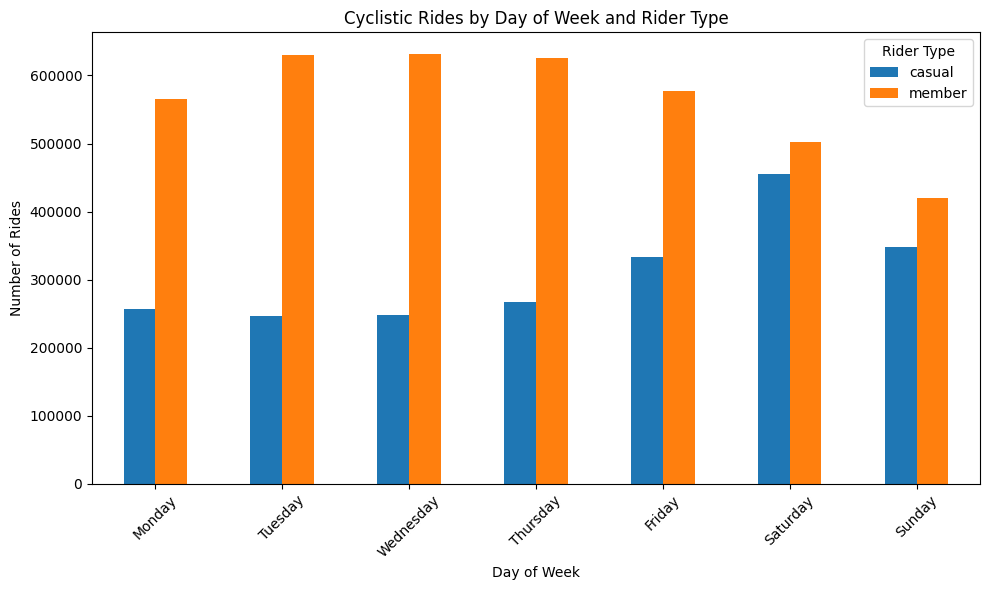

In [24]:
import matplotlib.pyplot as plt

rides_by_day.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cyclistic Rides by Day of Week and Rider Type")
plt.xlabel("Day of Week")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
plt.legend(title="Rider Type")
plt.tight_layout()
plt.show()

### 4.4 Monthly Riding Patterns

Monthly ride activity was analyzed to identify seasonal differences in how casual riders and annual members use Cyclistic. Comparing the two groups across the 12-month period helps determine whether casual rider activity is more sensitive to seasonal conditions than member activity.

In [25]:
month_order = [
    "September", "October", "November", "December",
    "January", "February", "March", "April",
    "May", "June", "July", "August"
]

rides_by_month = (
    cyclistic_clean
    .groupby(["month", "member_casual"])
    .size()
    .unstack()
    .reindex(month_order)
)

rides_by_month

member_casual,casual,member
month,,
September,264772,449202
October,223569,421921
November,98871,257292
December,28005,112415
January,24656,112933
February,41088,160251
March,87631,229121
April,131223,316675
May,244654,408510


#### Key Finding

Both annual members and casual riders show strong seasonal riding patterns. Ride activity declines substantially during the winter months and increases during spring and summer.

Casual rider activity is particularly seasonal. Casual rides decreased from 264,772 in September to only 24,656 in January before increasing to a peak of 357,121 in July.

Annual member activity also declined during the winter, but remained substantially higher than casual rider activity throughout the year. Member rides reached their highest level in August with 520,923 rides.

These results suggest that casual rider behavior is more strongly concentrated during warmer months, while annual members use Cyclistic more consistently throughout the year

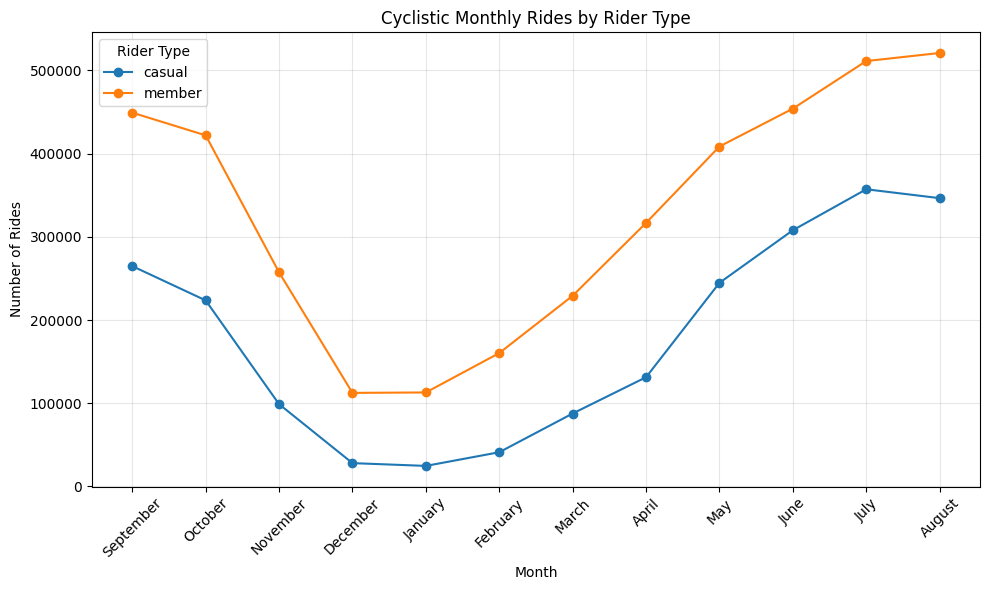

In [26]:
rides_by_month.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Cyclistic Monthly Rides by Rider Type")
plt.xlabel("Month")
plt.ylabel("Number of Rides")
plt.xticks(
    range(len(month_order)),
    month_order,
    rotation=45
)
plt.legend(title="Rider Type")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Rides by Hour of Day

Ride activity was analyzed by hour of the day to identify differences in daily usage patterns between casual riders and annual members.

This analysis can help determine whether member activity is concentrated around typical morning and evening travel periods, while casual rider activity follows a different daily pattern.

In [21]:
rides_by_hour = (
    cyclistic_clean
    .groupby(["hour", "member_casual"])
    .size()
    .unstack()
)

rides_by_hour

member_casual,casual,member
hour,,
0,46730,37307
1,30692,22734
2,19410,13418
3,11094,8747
4,8863,9853
5,13901,38464
6,29744,112210
7,53705,222028
8,76939,287997


#### Key Finding

Annual members show pronounced morning and evening peaks in ride activity. Member rides rise sharply during the morning, reaching 287,913 rides at 8 AM, and reach their highest hourly level at 5 PM with 426,624 rides.

Casual rider activity follows a different pattern. Casual rides increase more gradually throughout the day and reach their highest level at 5 PM with 204,162 rides, without the pronounced morning peak observed among members.

Combined with the stronger weekday activity identified earlier, the morning and evening peaks among members are consistent with more routine travel patterns, such as commuting. Casual rider behavior appears less concentrated around traditional morning travel hours.

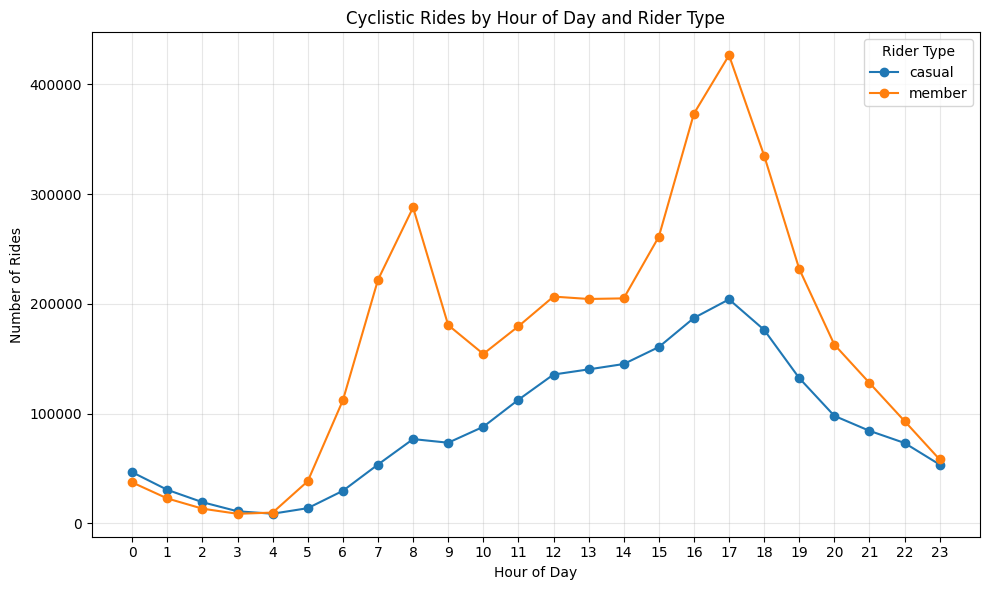

In [28]:
rides_by_hour.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Cyclistic Rides by Hour of Day and Rider Type")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.xticks(range(0, 24))
plt.legend(title="Rider Type")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.7 Bike Type Preference

Bike type usage was compared between casual riders and annual members to determine whether the two rider groups show different preferences for electric and classic bikes.

In [12]:
bike_type_summary = (
    cyclistic_clean
    .groupby(["rideable_type", "member_casual"])
    .size()
    .unstack()
)

bike_type_summary

member_casual,casual,member
rideable_type,,
classic_bike,570296,1263522
electric_bike,1590057,2692072


#### Bike Type Usage by Percentage

Because annual members account for more total rides than casual riders, raw ride counts alone do not provide a complete comparison of bike preferences. To make the groups more comparable, bike type usage was calculated as a percentage of total rides within each rider group.

This allows us to determine whether casual riders and annual members differ in their relative use of electric and classic bikes.

In [13]:
bike_type_pct = (
    bike_type_summary
    .div(bike_type_summary.sum(axis=0), axis=1)
    .mul(100)
    .round(2)
)

bike_type_pct

member_casual,casual,member
rideable_type,,
classic_bike,26.4,31.94
electric_bike,73.6,68.06


#### Key Finding

Electric bikes are the most commonly used bike type among both rider groups. They account for 73.60% of casual rides and 68.06% of member rides.

Casual riders therefore show a somewhat greater preference for electric bikes, while annual members have a slightly higher share of classic-bike usage. However, the difference between the groups is relatively modest compared with the differences observed in weekly, seasonal, and hourly riding patterns.

### 4.8 Ride Duration by Day of the Week

Average ride duration was compared across the days of the week for casual riders and annual members. This analysis helps determine whether the longer ride durations observed among casual riders are consistent throughout the week or become more pronounced on weekends.

In [15]:
# Make sure started_at is datetime
cyclistic_clean["started_at"] = pd.to_datetime(
    cyclistic_clean["started_at"]
)

# Recreate analysis variables
cyclistic_clean["date"] = cyclistic_clean["started_at"].dt.date
cyclistic_clean["day_of_week"] = cyclistic_clean["started_at"].dt.day_name()
cyclistic_clean["month"] = cyclistic_clean["started_at"].dt.month_name()
cyclistic_clean["hour"] = cyclistic_clean["started_at"].dt.hour

# Define weekday order again
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

print(cyclistic_clean.columns.tolist())

['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual', 'ride_length_min', 'date', 'day_of_week', 'month', 'hour']


In [16]:
duration_by_day = (
    cyclistic_clean
    .groupby(["day_of_week", "member_casual"])["ride_length_min"]
    .mean()
    .unstack()
    .reindex(day_order)
    .round(2)
)

duration_by_day

member_casual,casual,member
day_of_week,,
Monday,20.73,12.07
Tuesday,18.04,11.92
Wednesday,17.25,11.85
Thursday,18.01,11.91
Friday,20.21,12.31
Saturday,23.18,13.60
Sunday,24.28,13.49


#### Key Finding

Casual riders have longer average ride durations than annual members on every day of the week. The difference becomes especially pronounced on weekends.

Casual riders average 23.18 minutes per ride on Saturday and 24.28 minutes on Sunday, compared with 13.60 and 13.49 minutes for annual members.

Member ride duration remains relatively consistent throughout the week, while casual ride duration increases noticeably on weekends. Combined with the higher weekend ride activity observed earlier, this pattern suggests that casual riders may be more likely to use Cyclistic for longer recreational or leisure-oriented trips.

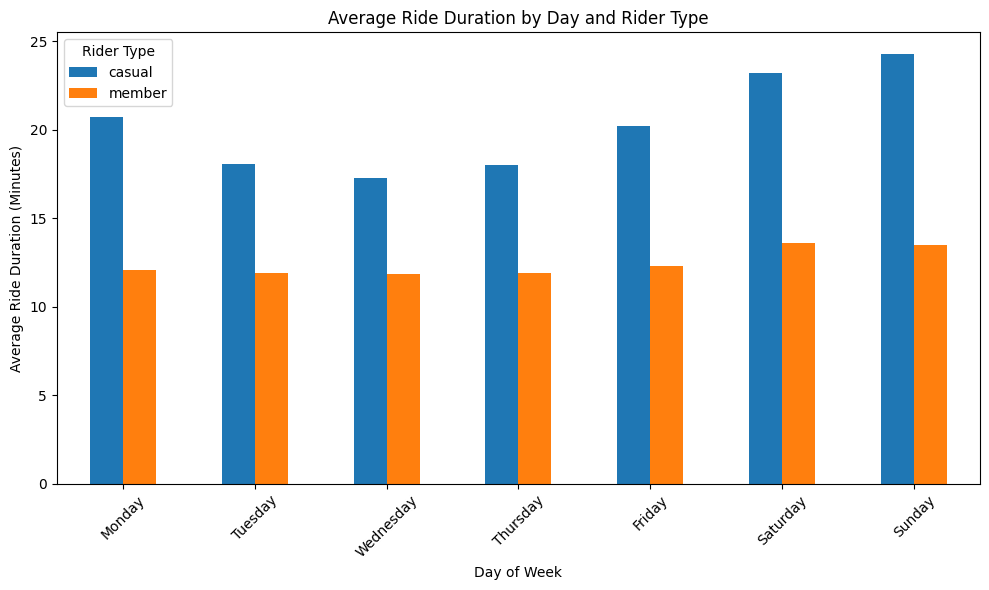

In [20]:
import matplotlib.pyplot as plt

duration_by_day.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Ride Duration by Day and Rider Type")
plt.xlabel("Day of Week")
plt.ylabel("Average Ride Duration (Minutes)")
plt.xticks(rotation=45)
plt.legend(title="Rider Type")
plt.tight_layout()
plt.show()

# 5. Share

The Share phase communicates the most important findings from the analysis and connects them to Cyclistic's business objective: understanding how casual riders and annual members use the bike-share service differently.

The analysis reveals several clear differences in riding frequency, ride duration, weekly patterns, seasonal patterns, and time-of-day usage.

## 5.1 Key Findings

### Rider Activity
Annual members account for 64.72% of rides, compared with 35.28% for casual riders. This indicates that members use Cyclistic more frequently overall.

### Ride Duration
Casual riders take longer trips, averaging 17.78 minutes per ride compared with 11.97 minutes for annual members. The difference becomes even more pronounced on weekends, when casual rides average 23.18 minutes on Saturday and 24.28 minutes on Sunday.

### Weekly Patterns
Member activity is strongest during the workweek, with the highest number of rides occurring on Wednesday. Casual riding increases toward the weekend and peaks on Saturday.

### Time-of-Day Patterns
Members show pronounced morning and evening peaks, particularly around 8 AM and 5 PM. Casual activity increases more gradually throughout the day and does not show the same strong morning peak. Together with the weekday pattern, this is consistent with members using Cyclistic more often for routine transportation, although trip purpose cannot be determined directly from the dataset.

### Seasonal Patterns
Both rider groups use Cyclistic less during the winter and more during warmer months. Casual ridership shows a particularly strong seasonal pattern, reaching its highest level during the summer.

### Bike Type
Electric bikes are the most frequently used bike type for both groups. They account for 73.60% of casual rides and 68.06% of member rides, indicating a modestly higher share of electric-bike usage among casual riders.

## 5.2 Main Business Insight

The strongest distinction between the two rider groups is not simply how many rides they take, but when and how they use Cyclistic.

Annual members ride more frequently, show stronger weekday and morning/evening usage patterns, and take shorter rides on average. Casual riders take fewer rides overall but ride for longer periods, particularly on weekends, and their usage is more concentrated during warmer months.

These patterns suggest that casual riders may represent an important membership-conversion opportunity during weekends and high-ridership summer months. Marketing efforts can therefore be focused on the times and usage patterns where casual riders are most active.

# 6. Act

The Act phase translates the findings from the analysis into practical recommendations that Cyclistic's marketing team could use to encourage casual riders to become annual members.

Based on the differences observed between casual riders and annual members, three strategies are recommended.

## 6.1 Business Recommendations

### 1. Target Casual Riders During Weekends and High-Ridership Months

Casual ridership increases toward the weekend, peaks on Saturday, and is substantially higher during the warmer months. Cyclistic could concentrate membership campaigns during these periods when casual riders are most actively using the service.

Digital promotions, in-app messages, and other targeted campaigns during weekends and high-ridership months could provide opportunities to introduce frequent casual riders to annual membership.

### 2. Develop Campaigns Around Longer Recreational Riding Patterns

Casual riders take longer trips than annual members on every day of the week, with the longest average rides occurring on Saturday and Sunday. Marketing messages aimed at these riders could emphasize how an annual membership may fit customers who use Cyclistic repeatedly for longer weekend and recreational trips.

Because the dataset does not identify the actual purpose of each trip, recreational use should be treated as a likely pattern rather than a confirmed explanation.

### 3. Target Casual Riders Who Frequently Use Electric Bikes

Electric bikes account for 73.60% of casual rides, compared with 68.06% of member rides. Although the difference is modest, electric bikes are clearly important to both groups and especially prominent among casual riders.

Cyclistic could test membership campaigns targeted toward repeat casual electric-bike users and evaluate whether this group responds differently to membership offers.

## 6.2 Conclusion

The analysis shows meaningful differences in how casual riders and annual members use Cyclistic.

Annual members account for the majority of rides and display stronger weekday and morning/evening riding patterns, while casual riders take longer rides, ride more heavily on weekends, and show greater seasonal variation.

These findings suggest that Cyclistic's strongest opportunities to reach casual riders occur during weekends and high-ridership months. Rather than marketing annual membership to all casual riders in the same way, Cyclistic could use these behavioral patterns to develop more targeted campaigns.

Future analysis could evaluate individual campaign performance through controlled experiments such as A/B testing to determine which messages and offers are most effective at converting casual riders into annual members.